**Intructions from Riccardo:**

I think it would be great if you could do the following until next week, either using OSMnx OR [R5py](https://r5py.readthedocs.io/stable/user-guide/user-manual/travel-time-matrices.html) (latter probs more realistic)

- With OSMNx
    - Can you please get the OSMNx graph, check that it overlaps well with the Framingham bounds (maybe take the polygon of the neighborhood and add a buffer around it, then use that to get the graph) and store it as a networkx graph.
    - Check if the graph looks OK (one node per intersection, not too many edges)
    - Add nodes for depot, schools, and stops (i.e. for the stops you probably want to just add a node type "school", "stop", "depot") to the network
- Create a fully connected graph stops x schools x depot
- Fill each edge's time and distance by running either 
    - NetworkX shortest path algorithm between all stops x schools x depot OR
    - R5py which is probably more accurate and you have less complexity to check the graph because R5 does smart stuff for you with OSM
- In the end, we just need this graph with connections between all stops x schools x depot and it should be a repeatable process when they change their stops in the future (not our problem).
- Finally, please generate a dataframe that maps students to their closest stop (you can again use R5py or the OSMNx graph to compute walking times for the assignment). If the students are under a certain walking/driving time or distance from their school assign them directly to the school so we don't assign them to a stop and we can discard them.

In [1]:
import os
import datetime as dt

os.environ["JAVA_HOME"] = os.path.join("C:", "Program Files", "Java", "jdk-25.0.2")

import geopandas as gpd
import pandas as pd
import networkx as nx
import osmnx as ox

import shapely
from shapely.geometry import Point

In [2]:
# where
PLACE_NAME = "Framingham, Massachusetts, USA"
BOUNDARY_BUFFER_M = 1000

# data files
DEPOT_CSV   = "data/depot.csv"
SCHOOLS_CSV = "data/schools.csv"
STOPS_CSV   = "data/stops.csv"
STUDENTS_CSV= "data/students.csv"

# thresholds
MAX_WALK_TIME_S = 15 * 60 # 15 mins
MAX_WALK_DIST_M = 1000 # 1 km (should we do miles? idk)

# base street network
NETWORK_TYPE = "drive"

# outputs
GRAPHML_FILE = "outputs/framingham_graph.graphml"
PAIRWISE_CSV = "outputs/depot_schools_stops_pairwise.csv"
STUDENT_ASSIGN_CSV = "outputs/student_to_stop_or_school.csv"

In [29]:
# get boundary polygon (similar to analysis.ipynb)
framingham_gdf = ox.geocode_to_gdf(PLACE_NAME)
framingham_poly = framingham_gdf.geometry.iloc[0]

# buffer the boundary polygon (consider changing this to a geodesic buffer?)
# framingham_buffered = shapely.buffer(framingham_poly, BOUNDARY_BUFFER_M)

# download street network
G = ox.graph_from_polygon(framingham_poly, network_type=NETWORK_TYPE)

# simplify
G = ox.truncate.largest_component(G, strongly=False)
# G = ox.simplify_graph(G)

# save as graphml for :sparkles: later :sparkles:
os.makedirs(os.path.dirname(GRAPHML_FILE), exist_ok=True)
ox.save_graphml(G, GRAPHML_FILE)

G

Number of nodes: 2023
Number of edges: 4961
Min degree: 1
Max degree: 8
Mean degree: 4.904597132970835


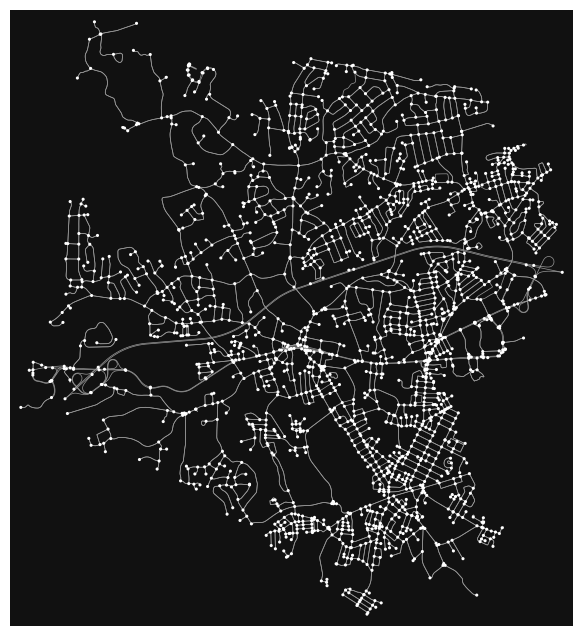

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [4]:
# sanity checks <3

# nodes v edges
print("Number of nodes:", len(G.nodes))
print("Number of edges:", len(G.edges))

# degree distribution
degrees = [deg for _, deg in G.degree()]
print("Min degree:", min(degrees))
print("Max degree:", max(degrees))
print("Mean degree:", sum(degrees) / len(degrees))

# plot map rq
ox.plot_graph(G, node_size=5, edge_linewidth=0.5)

# note for self: make sure only one node per intersection/dead end,
# and that there are no duplicate edges or goofy artifacts

In [5]:
def load_points_csv(path, id_col="id", lon_col="lon", lat_col="lat", node_type="stop"):
    df = pd.read_csv(path)
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
        crs="EPSG:4326"
    )
    gdf["node_type"] = node_type
    gdf["node_id"] = gdf[id_col].astype(str)
    return gdf

depot_gdf   = load_points_csv(DEPOT_CSV,   id_col="id", lon_col="lon", lat_col="lat", node_type="depot")
schools_gdf = load_points_csv(SCHOOLS_CSV, id_col="id", lon_col="lon", lat_col="lat", node_type="school")
stops_gdf   = load_points_csv(STOPS_CSV,   id_col="id", lon_col="lon", lat_col="lat", node_type="stop")

# combine into one gdf
poi_gdf = pd.concat([depot_gdf, schools_gdf, stops_gdf], ignore_index=True)

# map to nearest node
poi_gdf["nearest_node"] = ox.nearest_nodes(
    G,
    X=poi_gdf.geometry.x,
    Y=poi_gdf.geometry.y
)

# tag existing nodes 
for _, row in poi_gdf.iterrows():
    n = int(row["nearest_node"])
    # store lists in case multiple POIs map to same node
    G.nodes[n].setdefault("poi_ids", []).append(row["node_id"])
    G.nodes[n].setdefault("poi_types", []).append(row["node_type"])

poi_gdf.head()

,id,lon,lat,geometry,node_type,node_id,nearest_node
0,DEPOT,-71.431644,42.275978,POINT (-71.43164 42.27598),depot,DEPOT,61394664
1,THAYER CAMPUS,-71.411640,42.282753,POINT (-71.41164 42.28275),school,THAYER CAMPUS,61453969
2,BAR,-71.432341,42.279627,POINT (-71.43234 42.27963),school,BAR,3129763534
3,BRO,-71.463880,42.306510,POINT (-71.46388 42.30651),school,BRO,61439632
4,CAM,-71.399944,42.333209,POINT (-71.39994 42.33321),school,CAM,61446288


In [39]:
stops_gdf

# get all rows where the ID doesn't include a digit (i.e. non-numeric stop IDs)
no_num = stops_gdf["id"].str.findall(r'\D')  # Find all non-digit characters in the 'id' column

no_num.value_counts()

id
[ , G, R, O, V, E,  , S, T]                                                                                  10
[ , P, L, E, A, S, A, N, T,  , S, T]                                                                          9
[ , S, A, L, E, M,  , E, N, D,  , R, D]                                                                       9
[ , E, D, G, E, L, L,  , R, D]                                                                                8
[ , E, D, M, A, N, D, S,  , R, D]                                                                             8
                                                                                                             ..
[H, A, R, T, F, O, R, D,  , S, T,  , &,  , E, L, I, O, T,  , S, T]                                            1
[ , A, U, B, U, R, N,  , S, T]                                                                                1
[ , C,  , S, T]                                                                                      

In [6]:
# yoink mapping in graph node
poi_to_node = poi_gdf.set_index("node_id")["nearest_node"].to_dict()

depot_ids   = depot_gdf["node_id"].tolist()
school_ids  = schools_gdf["node_id"].tolist()
stop_ids    = stops_gdf["node_id"].tolist()

# Graph node sets
depot_nodes  = [poi_to_node[i] for i in depot_ids]
school_nodes = [poi_to_node[i] for i in school_ids]
stop_nodes   = [poi_to_node[i] for i in stop_ids]

print("Depot nodes:", depot_nodes)
print("School nodes:", school_nodes)
print("Stop nodes:", stop_nodes)

Depot nodes: [61394664]
School nodes: [61453969, 3129763534, 61439632, 61446288, 61445928, 61450541, 7149569552, 61449559, 61407188, 61450541, 61411371, 61454036, 61471378, 61471378, 3071082062, 61458180, 61453969, 61460395]
Stop nodes: [61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61

In [7]:
# build fully connected graph between depots, schools, and stops
# edge weights are shortest path distance and time in G

# make sure all edges have lengths (eg are weighted)
assert all("length" in data for _, _, data in G.edges(data=True))

# just in case...
if not all("speed_kph" in data for _, _, data in G.edges(data=True)):
    print("Adding edge speeds...")
    G = ox.add_edge_speeds(G)
if not all("travel_time" in data for _, _, data in G.edges(data=True)):
    print("Adding edge travel times...")
    G = ox.add_edge_travel_times(G)

def shortest_path_metrics(G, orig, dest, weight="travel_time") -> tuple[float, float]:
    """
    Returns (distance_m, time_s) for shortest path between orig and dest.
    """
    path = nx.shortest_path(G, orig, dest, weight=weight)  # [web:5]
    # Sum distances and times along path
    dist_m = 0.0
    time_s = 0.0
    for u, v in zip(path[:-1], path[1:]):
        edge_data = min(G[u][v].values(), key=lambda d: d.get(weight, 0))
        dist_m += edge_data.get("length", 0.0)
        time_s += edge_data.get("travel_time", 0.0)
    return dist_m, time_s

# complete graph over poi nodes
poi_node_ids = depot_ids + school_ids + stop_ids
poi_node_types = (
    ["depot"] * len(depot_ids)
    + ["school"] * len(school_ids)
    + ["stop"] * len(stop_ids)
)

# new complete graph
K = nx.Graph()
for pid, ptype in zip(poi_node_ids, poi_node_types):
    K.add_node(pid, node_type=ptype)

# pairwise metrics
records = []

for i, pid1 in enumerate(poi_node_ids):
    n1 = poi_to_node[pid1]
    for j in range(i + 1, len(poi_node_ids)):
        pid2 = poi_node_ids[j]
        n2 = poi_to_node[pid2]

        dist_m, time_s = shortest_path_metrics(G, n1, n2, weight="travel_time")

        # store edge in K
        K.add_edge(
            pid1,
            pid2,
            distance_m=dist_m,
            travel_time_s=time_s
        )

        records.append(
            {
                "origin_id": pid1,
                "dest_id": pid2,
                "distance_m": dist_m,
                "travel_time_s": time_s,
            }
        )

pairwise_df = pd.DataFrame(records)
os.makedirs(os.path.dirname(PAIRWISE_CSV), exist_ok=True)
pairwise_df.to_csv(PAIRWISE_CSV, index=False)
pairwise_df.head()

Adding edge speeds...
Adding edge travel times...


,origin_id,dest_id,distance_m,travel_time_s
0,DEPOT,THAYER CAMPUS,2278.963273,176.559114
1,DEPOT,BAR,74.608443,5.125531
2,DEPOT,BRO,6476.426306,466.949924
3,DEPOT,CAM,8453.878338,612.942637
4,DEPOT,DUN,6328.635963,466.176742


In [8]:
# we also have .pbf so we could do r5py?

import r5py

OSM_PBF = "data/framingham.osm.pbf"

transport_network = r5py.TransportNetwork(OSM_PBF)
poi_all_gdf = poi_gdf[["node_id", "geometry"]].copy()
origins = poi_all_gdf.rename(columns={"node_id": "id"})
destinations = origins.copy()

ttm = r5py.TravelTimeMatrix(
    transport_network,
    origins=origins,
    destinations=destinations,
    transport_modes=[r5py.TransportMode.CAR],  # or WALK, TRANSIT, etc.
    departure=dt.datetime(2026, 9, 1, 8, 0, 0),
)

ttm.head()

,from_id,to_id,travel_time
0,DEPOT,DEPOT,0.0
1,DEPOT,THAYER CAMPUS,5.0
2,DEPOT,BAR,4.0
3,DEPOT,BRO,10.0
4,DEPOT,CAM,14.0


In [9]:
# assign students to nearest stop or school

from functools import cache

# load students
students_df = pd.read_csv(STUDENTS_CSV)
students_gdf = gpd.GeoDataFrame(
    students_df,
    geometry=gpd.points_from_xy(students_df["lon"], students_df["lat"]),
    crs="EPSG:4326"
)

# map to nearest node
students_gdf["nearest_node"] = ox.nearest_nodes(
    G,
    X=students_gdf.geometry.x,
    Y=students_gdf.geometry.y
) 

@cache
def shortest_to_targets(G, origin_node, target_nodes, weight="travel_time"):
    """
    Return DataFrame of distances/times from origin_node to each node in target_nodes.
    """
    # Single-source Dijkstra to all nodes
    dist_time = nx.single_source_dijkstra_path_length(G, origin_node, weight=weight)

    records = []
    for t in target_nodes:
        # recompute distance in meters along shortest path (to mirror earlier)
        try:
            path = nx.shortest_path(G, origin_node, t, weight=weight)
        except nx.NetworkXNoPath:
            continue
        dist_m = 0.0
        for u, v in zip(path[:-1], path[1:]):
            edge_data = min(G[u][v].values(), key=lambda d: d.get(weight, 0))
            dist_m += edge_data.get("length", 0.0)

        time_s = dist_time.get(t, None)
        if time_s is None:
            continue

        records.append(
            {"target_node": t, "distance_m": dist_m, "travel_time_s": time_s}
        )

    return pd.DataFrame(records)

# store mapping from school/stop ids to node ids
school_node_by_id = {sid: poi_to_node[sid] for sid in school_ids}
stop_node_by_id   = {sid: poi_to_node[sid] for sid in stop_ids}

school_nodes = list(school_node_by_id.values())
stop_nodes   = list(stop_node_by_id.values())

print("School nodes:", school_nodes)
print("Stop nodes:", stop_nodes)

School nodes: [61453969, 3129763534, 61439632, 61446288, 61445928, 61450541, 7149569552, 61449559, 61407188, 61450541, 61411371, 61454036, 61471378, 61471378, 3071082062, 61458180, 61453969, 61460395]
Stop nodes: [61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 61446761, 614467

In [11]:
# for each student, find nearest school/stop within thresholds
# if closest school within threshold, assign to school, else stop

assign_records = []

for idx, stu in students_gdf.iterrows():
    stu_id = stu["student_id"]
    s_node = int(stu["nearest_node"])

    # distances to schoools
    df_sch = shortest_to_targets(G, s_node, tuple(school_nodes), weight="travel_time")
    if df_sch.empty:
        # rip
        continue

    min_sch = df_sch.loc[df_sch["travel_time_s"].idxmin()]  # by minimal time
    closest_school_node = int(min_sch["target_node"])
    closest_school_time = float(min_sch["travel_time_s"])
    closest_school_dist = float(min_sch["distance_m"])

    # map back to original school id
    # inv_school_node = {v: k for k, v in school_node_by_id.items()}
    # closest_school_id = inv_school_node[closest_school_node]
    closest_school_id = list(school_node_by_id.keys())[list(school_node_by_id.values()).index(closest_school_node)]

    # distances to stops
    df_stops = shortest_to_targets(G, s_node, tuple(stop_nodes), weight="travel_time")
    if df_stops.empty:
        # RIP AGAIN </3
        continue
    
    min_stop = df_stops.loc[df_stops["travel_time_s"].idxmin()]
    closest_stop_node = int(min_stop["target_node"])
    closest_stop_time = float(min_stop["travel_time_s"])
    closest_stop_dist = float(min_stop["distance_m"])

    # same as with schools, map back to stop id
    # inv_stop_node = {v: k for k, v in stop_node_by_id.items()}
    # closest_stop_id = inv_stop_node[closest_stop_node]
    closest_stop_id = list(stop_node_by_id.keys())[list(stop_node_by_id.values()).index(closest_stop_node)]

    # decide assignment based on thresholds
    if (closest_school_time <= MAX_WALK_TIME_S) or (closest_school_dist <= MAX_WALK_DIST_M):
        assignment_type = "direct_school"
        assigned_to = closest_school_id
    else:
        assignment_type = "stop"
        assigned_to = closest_stop_id

    if idx < 5:  # print first few for sanity check
        print(f"Student {stu_id} assigned to {assignment_type} {assigned_to}")
        
    assign_records.append(
        {
            "student_id": stu_id,
            "school_id_closest": closest_school_id,
            "school_time_s": closest_school_time,
            "school_distance_m": closest_school_dist,
            "stop_id_closest": closest_stop_id,
            "stop_time_s": closest_stop_time,
            "stop_distance_m": closest_stop_dist,
            "assignment_type": assignment_type,
            "assigned_to": assigned_to,
        }
    )
    
student_assign_df = pd.DataFrame(assign_records)
os.makedirs(os.path.dirname(STUDENT_ASSIGN_CSV), exist_ok=True)
student_assign_df.to_csv(STUDENT_ASSIGN_CSV, index=False)
student_assign_df.head()

Student 1 assigned to direct_school HAR
Student 2 assigned to direct_school BAR
Student 3 assigned to direct_school THAYER CAMPUS
Student 4 assigned to direct_school THAYER CAMPUS
Student 5 assigned to direct_school HAR


,student_id,school_id_closest,school_time_s,school_distance_m,stop_id_closest,stop_time_s,stop_distance_m,assignment_type,assigned_to
0,1,HAR,49.073015,646.573663,SEMINOLE AV & FAY RD,510.342241,6890.852999,direct_school,HAR
1,2,BAR,142.338858,1927.487479,SEMINOLE AV & FAY RD,628.117898,8053.001765,direct_school,BAR
2,3,THAYER CAMPUS,13.748595,187.179259,SEMINOLE AV & FAY RD,395.206852,5279.302579,direct_school,THAYER CAMPUS
3,4,THAYER CAMPUS,13.758303,187.312729,SEMINOLE AV & FAY RD,379.020559,5048.046142,direct_school,THAYER CAMPUS
4,5,HAR,58.385488,802.671560,SEMINOLE AV & FAY RD,512.680174,6955.789669,direct_school,HAR


In [12]:
# quick check
student_assign_df["assignment_type"].value_counts()

assignment_type
direct_school    8356
Name: count, dtype: int64